# 서울시 100m 기본 격자 구축

## 목적
- 전국 100m 격자에서 서울시 격자만 추출
- 각 격자에 시군구·행정동 정보와 중심점 좌표 결합
- 후속 인구 추정에서 사용할 기본 공간 테이블 생성

In [1]:
import pathlib

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

## 경로 설정

In [2]:
BASE_PATH = pathlib.Path.cwd().resolve()

if not (BASE_PATH / "data").exists():
    for parent in BASE_PATH.parents:
        if (parent / "data").exists():
            BASE_PATH = parent
            break

RAW_PATH = BASE_PATH / "data" / "raw"
PROCESSED_PATH = BASE_PATH / "data" / "processed" / "spatial"

GRID_PATH = RAW_PATH / "spatial" / "grid" / "source"
BOUNDARY_PATH = RAW_PATH / "spatial" / "boundary"
OUTPUT_FILE = PROCESSED_PATH / "서울시_격자_100m_행정동_기본테이블.gpkg"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 경로: {BASE_PATH}")
print(f"저장 경로: {OUTPUT_FILE}")

프로젝트 경로: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project
저장 경로: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project\data\processed\spatial\서울시_격자_100m_행정동_기본테이블.gpkg


## 데이터 불러오기
- 전국 100m 격자
- 전국 행정동 경계
- 행정동 코드·명칭 매핑표

In [3]:
import sys
from pathlib import Path

print("Python:", sys.executable)
print("현재 위치:", Path.cwd())
print("BASE_PATH:", globals().get("BASE_PATH", "미설정"))

Python: c:\Users\ben20\miniconda3\envs\sda2025\python.exe
현재 위치: c:\Users\ben20\Documents\DataScience\projects\Oracle-Project
BASE_PATH: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project


In [4]:
required_files = [
    GRID_PATH / "grid_dasa_100M.shp",
    BOUNDARY_PATH / "BND_ADM_DONG_PG.shp",
    BOUNDARY_PATH / "BND_ADM_DONG_PG_geocode.xlsx",
]

missing_files = [path for path in required_files if not path.exists()]
assert not missing_files, f"필수 입력 파일 누락: {missing_files}"

grid_100 = gpd.read_file(required_files[0])
hjd = gpd.read_file(required_files[1], encoding="cp949")
hjd_code = pd.read_excel(required_files[2], sheet_name=0, header=1)

display(grid_100.head())
display(hjd.head())
display(hjd_code.head())

,GRID_CD,geometry
0,다사111174,"POLYGON ((911100 1917400, 911100 1917500, 9112..."
1,다사111175,"POLYGON ((911100 1917500, 911100 1917600, 9112..."
2,다사274015,"POLYGON ((927400 1901500, 927400 1901600, 9275..."
3,다사275015,"POLYGON ((927500 1901500, 927500 1901600, 9276..."
4,다사274016,"POLYGON ((927400 1901600, 927400 1901700, 9275..."


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((197702.069 553187.311, 197703.431 55..."
1,20250630,11010540,삼청동,"POLYGON ((197980.839 555346.068, 197995.421 55..."
2,20250630,11010550,부암동,"POLYGON ((196621.023 556395.88, 196628.324 556..."
3,20250630,11010560,평창동,"POLYGON ((197800.72 559064.245, 197782.581 558..."
4,20250630,11010570,무악동,"POLYGON ((196444.745 553384.564, 196471.618 55..."


,시도코드,시도명칭,시군구코드,시군구명칭,읍면동코드,읍면동명칭
0,11,서울특별시,10,종로구,530,사직동
1,11,서울특별시,10,종로구,540,삼청동
2,11,서울특별시,10,종로구,550,부암동
3,11,서울특별시,10,종로구,560,평창동
4,11,서울특별시,10,종로구,570,무악동


## 원본 데이터 품질 확인

In [5]:
source_check = pd.DataFrame({
    "데이터": ["100m 격자", "행정동 경계", "행정동 코드표"],
    "행 수": [len(grid_100), len(hjd), len(hjd_code)],
    "좌표계": [str(grid_100.crs), str(hjd.crs), "해당 없음"],
    "결측 geometry": [
        int(grid_100.geometry.isna().sum()),
        int(hjd.geometry.isna().sum()),
        None,
    ],
})

display(source_check)
print(f"100m 격자 geometry 유형: {grid_100.geometry.geom_type.unique()}")
print(f"행정동 geometry 유형: {hjd.geometry.geom_type.unique()}")
print(f"100m 격자 코드 중복: {grid_100['GRID_CD'].duplicated().sum():,}건")

assert grid_100.crs is not None
assert hjd.crs is not None
assert grid_100["GRID_CD"].duplicated().sum() == 0

,데이터,행 수,좌표계,결측 geometry
0,100m 격자,824637,"PROJCS[""Korea_2000_Korea_Unified_Coordinate_Sy...",0.0
1,행정동 경계,3559,EPSG:5186,0.0
2,행정동 코드표,3559,해당 없음,NaN


100m 격자 geometry 유형: <StringArray>
['Polygon']
Length: 1, dtype: str
행정동 geometry 유형: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str
100m 격자 코드 중복: 0건


c:\Users\ben20\miniconda3\envs\sda2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ben20\miniconda3\envs\sda2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ben20\miniconda3\envs\sda2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ben20\miniconda3\envs\sda2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ben20\miniconda3\envs\sda2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWA

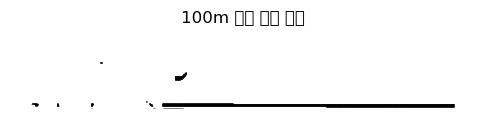

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
grid_100.iloc[:5000].plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    facecolor="none",
)
ax.set_title("100m 격자 구조 확인")
ax.set_axis_off()
plt.show()

## 서울시 행정동 경계 전처리

In [7]:
hjd_code = hjd_code[
    ["시도코드", "시군구코드", "시군구명칭", "읍면동코드", "읍면동명칭"]
].copy()

code_columns = ["시도코드", "시군구코드", "읍면동코드"]
hjd_code[code_columns] = hjd_code[code_columns].astype(str)
hjd_code["ADM_CD"] = (
    hjd_code["시도코드"].str.zfill(2)
    + hjd_code["시군구코드"].str.zfill(3)
    + hjd_code["읍면동코드"].str.zfill(3)
)

print("경계 ADM_CD 길이")
display(hjd["ADM_CD"].str.len().value_counts().sort_index())
print("코드표 ADM_CD 길이")
display(hjd_code["ADM_CD"].str.len().value_counts().sort_index())

hjd_join = hjd.merge(
    hjd_code,
    on="ADM_CD",
    how="left",
    validate="many_to_one",
)
hjd_seoul = hjd_join.loc[
    hjd_join["시도코드"] == "11",
    ["ADM_CD", "시군구명칭", "ADM_NM", "geometry"],
].copy()
hjd_seoul = hjd_seoul.rename(columns={
    "ADM_CD": "행정동코드",
    "시군구명칭": "시군구",
    "ADM_NM": "행정동",
})

boundary_check = pd.Series({
    "서울 행정동 경계 수": len(hjd_seoul),
    "시군구 수": hjd_seoul["시군구"].nunique(),
    "행정동 코드 수": hjd_seoul["행정동코드"].nunique(),
    "행정동 코드 중복": hjd_seoul["행정동코드"].duplicated().sum(),
    "행정구역 결측": int(
        hjd_seoul[["행정동코드", "시군구", "행정동"]].isna().sum().sum()
    ),
}, name="확인값")

display(boundary_check.to_frame())
assert boundary_check["행정구역 결측"] == 0

경계 ADM_CD 길이


ADM_CD
8    3559
Name: count, dtype: int64

코드표 ADM_CD 길이


ADM_CD
8    3559
Name: count, dtype: int64

,확인값
서울 행정동 경계 수,426
시군구 수,25
행정동 코드 수,426
행정동 코드 중복,0
행정구역 결측,0


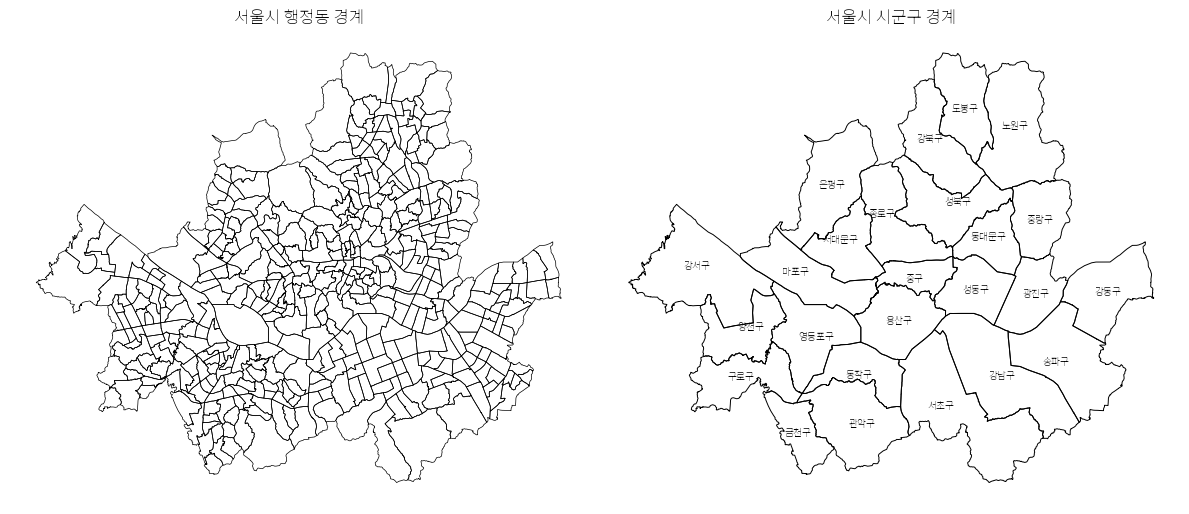

In [8]:
plt.rcParams["font.family"] = "Noto Sans KR"

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
hjd_seoul.plot(
    ax=axes[0],
    edgecolor="black",
    facecolor="none",
    linewidth=0.5,
)
axes[0].set_title("서울시 행정동 경계")
axes[0].set_axis_off()

sgg = hjd_seoul.dissolve(by="시군구").reset_index()
sgg.plot(
    ax=axes[1],
    edgecolor="black",
    facecolor="none",
    linewidth=0.7,
)

for _, row in sgg.iterrows():
    point = row.geometry.representative_point()
    axes[1].text(
        point.x,
        point.y,
        row["시군구"],
        fontsize=7,
        ha="center",
        va="center",
    )

axes[1].set_title("서울시 시군구 경계")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## 100m 격자와 행정동 결합
- 격자 중심점이 포함되는 행정동을 기준으로 공간 결합
- 모든 공간 연산은 100m 격자의 투영좌표계에서 수행

In [9]:
hjd_seoul = hjd_seoul.to_crs(grid_100.crs)
assert hjd_seoul.crs == grid_100.crs, "격자와 행정동 경계의 좌표계가 다릅니다."

grid_centroid = grid_100.copy()
grid_centroid["중심점"] = grid_centroid.geometry.centroid
grid_centroid = grid_centroid.set_geometry("중심점")

grid_join = grid_centroid.sjoin(
    hjd_seoul,
    how="inner",
    predicate="within",
)

grid_hjd = grid_100.merge(
    grid_join[["GRID_CD", "행정동코드", "시군구", "행정동"]],
    on="GRID_CD",
    how="inner",
    validate="one_to_one",
)
grid_hjd["중심점"] = grid_hjd.geometry.centroid

display(grid_hjd.head())

,GRID_CD,geometry,행정동코드,시군구,행정동,중심점
0,다사603367,"POLYGON ((960300 1936700, 960300 1936800, 9604...",11220670,서초구,양재2동,POINT (960350 1936750)
1,다사604367,"POLYGON ((960400 1936700, 960400 1936800, 9605...",11220670,서초구,양재2동,POINT (960450 1936750)
2,다사605367,"POLYGON ((960500 1936700, 960500 1936800, 9606...",11220670,서초구,양재2동,POINT (960550 1936750)
3,다사615367,"POLYGON ((961500 1936700, 961500 1936800, 9616...",11220680,서초구,내곡동,POINT (961550 1936750)
4,다사602368,"POLYGON ((960200 1936800, 960200 1936900, 9603...",11220670,서초구,양재2동,POINT (960250 1936850)


## 결과 품질 점검

,확인값
서울 100m 격자 수,60528
격자 코드 중복,0
전체 결측값,0
시군구 수,25
행정동 코드 수,426
유효하지 않은 geometry,0


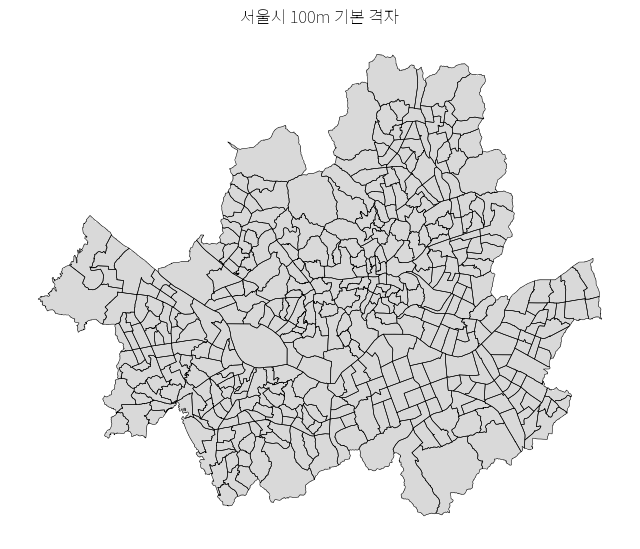

In [10]:
result_check = pd.Series({
    "서울 100m 격자 수": len(grid_hjd),
    "격자 코드 중복": grid_hjd["GRID_CD"].duplicated().sum(),
    "전체 결측값": int(grid_hjd.isna().sum().sum()),
    "시군구 수": grid_hjd["시군구"].nunique(),
    "행정동 코드 수": grid_hjd["행정동코드"].nunique(),
    "유효하지 않은 geometry": int((~grid_hjd.geometry.is_valid).sum()),
}, name="확인값")

display(result_check.to_frame())

assert result_check["격자 코드 중복"] == 0
assert result_check["전체 결측값"] == 0
assert result_check["유효하지 않은 geometry"] == 0
assert result_check["시군구 수"] == 25

fig, ax = plt.subplots(figsize=(8, 8))
grid_hjd.plot(ax=ax, facecolor="#d9d9d9", edgecolor="none")
hjd_seoul.boundary.plot(ax=ax, color="black", linewidth=0.4)
ax.set_title("서울시 100m 기본 격자")
ax.set_axis_off()
plt.show()

## 결과 저장

In [11]:
grid_hjd_save = grid_hjd.copy()
grid_hjd_save["중심점_x"] = grid_hjd_save["중심점"].x
grid_hjd_save["중심점_y"] = grid_hjd_save["중심점"].y
grid_hjd_save = grid_hjd_save.drop(columns="중심점")

if OUTPUT_FILE.exists():
    OUTPUT_FILE.unlink()

grid_hjd_save.to_file(OUTPUT_FILE, driver="GPKG")
print(f"저장 완료: {OUTPUT_FILE}")

저장 완료: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project\data\processed\spatial\서울시_격자_100m_행정동_기본테이블.gpkg


## 기존 결과와 비교
- 이전 기본격자와 격자 목록, 행정구역 속성, 중심점 좌표, geometry 비교

## 주요 결과 요약

In [12]:
summary = pd.Series({
    "저장 파일": OUTPUT_FILE.name,
    "서울 100m 격자 수": f"{len(grid_hjd_save):,}",
    "시군구 수": grid_hjd_save["시군구"].nunique(),
    "행정동 수": grid_hjd_save["행정동코드"].nunique(),
    "결측값": int(grid_hjd_save.isna().sum().sum()),
    "격자 코드 중복": int(grid_hjd_save["GRID_CD"].duplicated().sum()),
}, name="결과")

display(summary.to_frame())

,결과
저장 파일,서울시_격자_100m_행정동_기본테이블.gpkg
서울 100m 격자 수,"60,528"
시군구 수,25
행정동 수,426
결측값,0
격자 코드 중복,0
